In [2]:
from pathlib import Path
import json
import os
import numpy as np
from tabulate import tabulate

ROOT = Path(r'C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto\Metrics_multilabel')

PATH_ASL  = ROOT / 'global_report_strategy_None_ASL.json'
PATH_NONE = ROOT / 'global_report_strategy_None_None.json'
PATH_PW   = ROOT / 'global_report_strategy_None_PW.json'
PATH_WS   = ROOT / 'global_report_strategy_WS_None.json'

def load_json(path, name):
    try:
        with open(path, 'r', encoding='utf-8') as f:
            return json.load(f)
    except Exception as e:
        print(f"Error leyendo el archivo {name}: {e}")
        return None

# Intentar cargar todos los datos
data_ASL = load_json(PATH_ASL, "None_ASL")
data_None = load_json(PATH_NONE, "None_None")
data_PW = load_json(PATH_PW, "None_PW")
data_WS = load_json(PATH_WS, "WS_None")

# Validar que todos los archivos se hayan leído correctamente
if not all([data_ASL, data_None, data_PW, data_WS]):
    print("\nEl script se detuvo porque falta configurar o cargar uno o más archivos JSON.")
    exit()

# Agrupación de los diccionarios cargados
methods = {
    "None_ASL": data_ASL,
    "None_None": data_None,
    "None_PW": data_PW,
    "WS_None": data_WS
}

# Mapeo de métricas: (Estrategia en el JSON, Nombre de la clave interna)
metrics_mapping = {
    "F1-Score (Default 0.5)": ("default_0.5", "f1_score"),
    "F1-Score (Optimized)": ("optimized", "f1_score"),
    "PR-AUC": ("independent", "PR-AUC"),
    "ROC-AUC": ("independent", "ROC-AUC"),
    "Umbrales Optimizados (Best Threshold)": ("optimized", "best_threshold")
}

classes = list(data_ASL.keys())

def calculate_macro(method_data, strategy, metric_name):
    """Calcula el promedio macro y propaga correctamente la desviación estándar."""
    means = []
    stds = []
    for c in classes:
        means.append(method_data[c][strategy][metric_name]["mean"])
        stds.append(method_data[c][strategy][metric_name]["std"])
    
    macro_mean = np.mean(means)
    # Propagación de errores para una media: sqrt(sum(std^2)) / N
    macro_std = np.sqrt(np.sum(np.square(stds))) / len(classes)
    return macro_mean, macro_std

# Bucle principal para generar las tres tablas comparativas
for label, (strat, dict_key) in metrics_mapping.items():
    print(f"\n" + "="*65)
    print(f" COMPARATIVA PARA LA MÉTRICA: {label}")
    print("="*65)
    
    table_data = []
    
    # Filas por cada clase/lesión
    for c in classes:
        row = [c]
        for m_name, m_data in methods.items():
            val_mean = m_data[c][strat][dict_key]["mean"]
            val_std = m_data[c][strat][dict_key]["std"]
            row.append(f"{val_mean:.4f} ± {val_std:.4f}")
        table_data.append(row)
    
    # Línea de separación visual para el promedio general
    table_data.append(["-"*25] + ["-"*18]*len(methods))
    
    # Fila final con el cálculo Macro
    macro_row = ["MACRO AVERAGE"]
    for m_name, m_data in methods.items():
        m_mean, m_std = calculate_macro(m_data, strat, dict_key)
        macro_row.append(f"{m_mean:.4f} ± {m_std:.4f}")
    table_data.append(macro_row)
    
    # Cabeceras de la tabla
    headers = ["Clase / Lesión"] + list(methods.keys())
    print(tabulate(table_data, headers=headers, tablefmt="grid"))


 COMPARATIVA PARA LA MÉTRICA: F1-Score (Default 0.5)
+---------------------------+--------------------+--------------------+--------------------+--------------------+
| Clase / Lesión            | None_ASL           | None_None          | None_PW            | WS_None            |
+===========================+====================+====================+====================+====================+
| normal                    | 0.7069 ± 0.0750    | 0.7923 ± 0.0417    | 0.7879 ± 0.0450    | 0.7572 ± 0.0351    |
+---------------------------+--------------------+--------------------+--------------------+--------------------+
| lowgrade_dysplasia        | 0.8102 ± 0.0761    | 0.8744 ± 0.0352    | 0.8699 ± 0.0349    | 0.8414 ± 0.0349    |
+---------------------------+--------------------+--------------------+--------------------+--------------------+
| inflammation              | 0.1635 ± 0.0612    | 0.0450 ± 0.0380    | 0.1578 ± 0.0570    | 0.1083 ± 0.0481    |
+---------------------------+-----

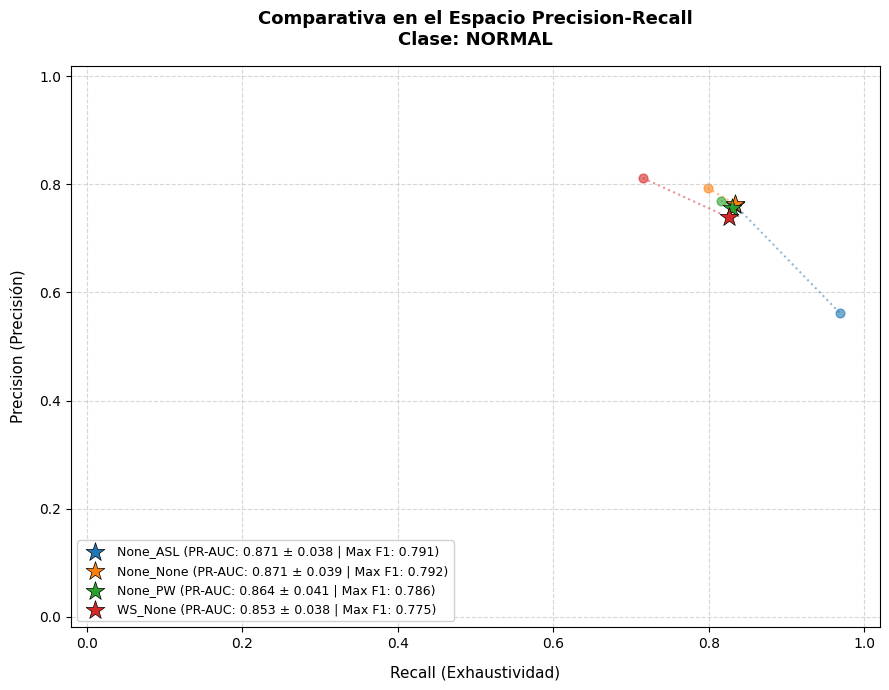

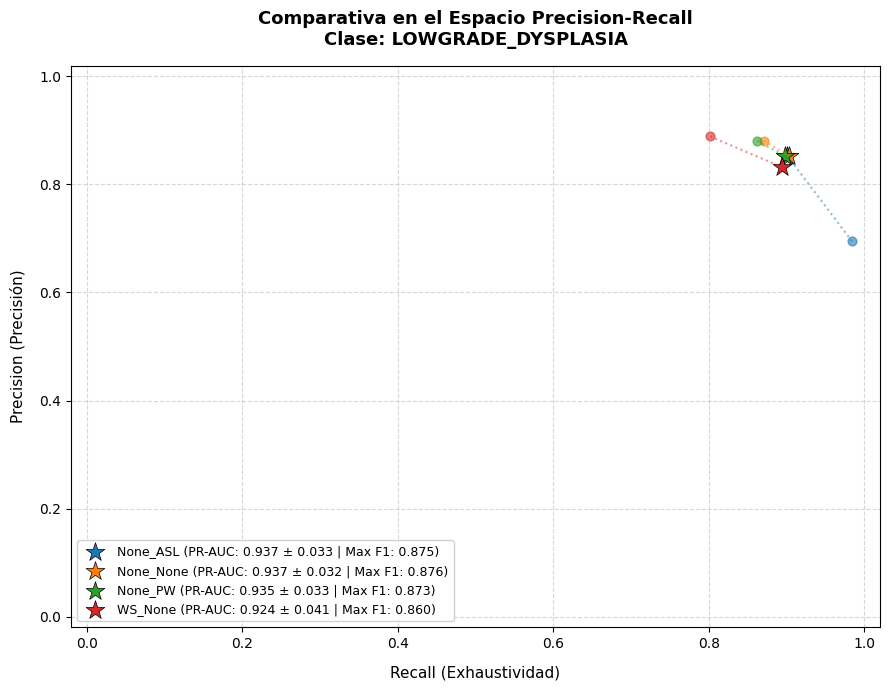

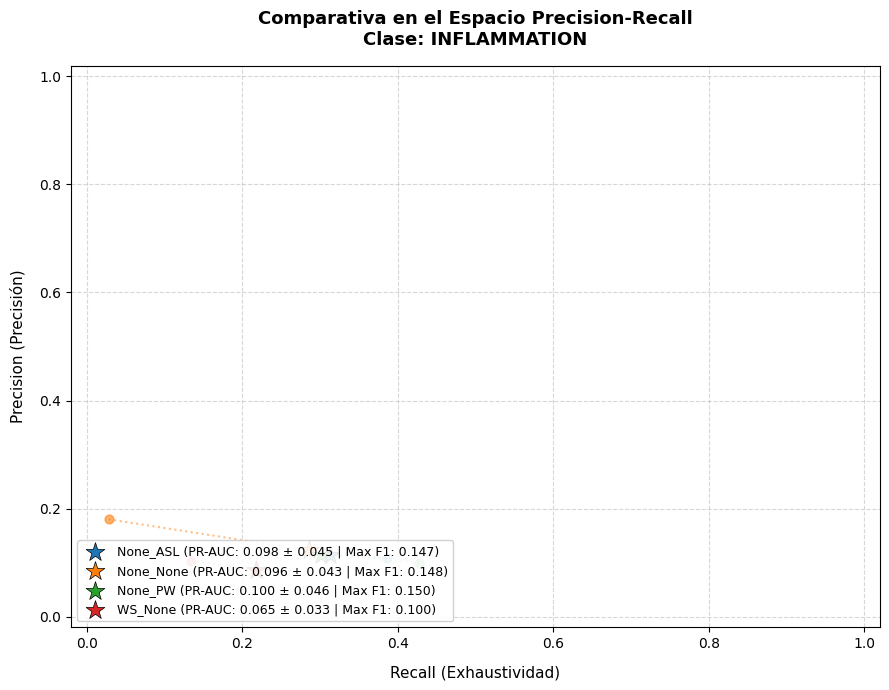

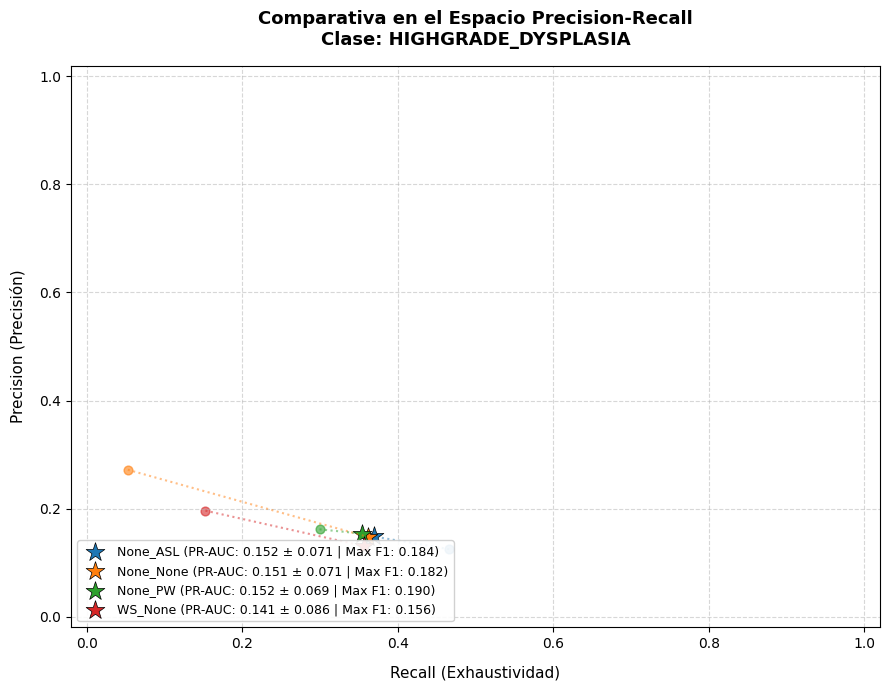

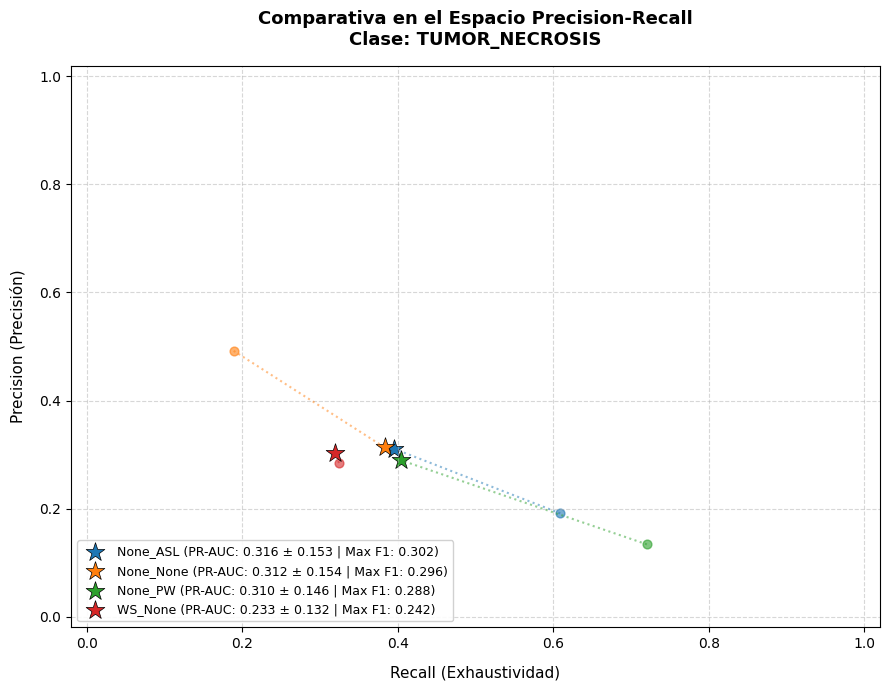

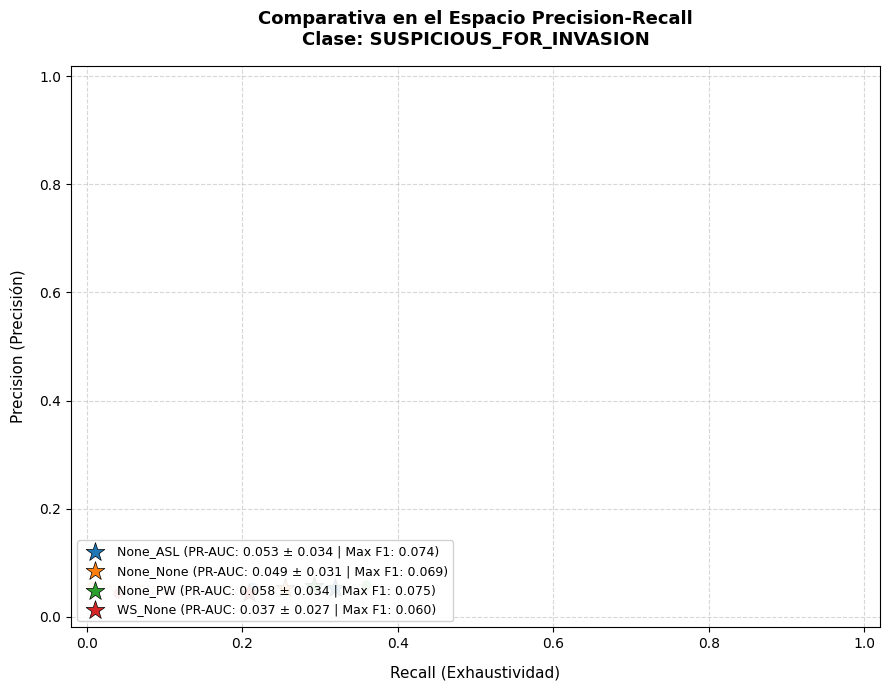

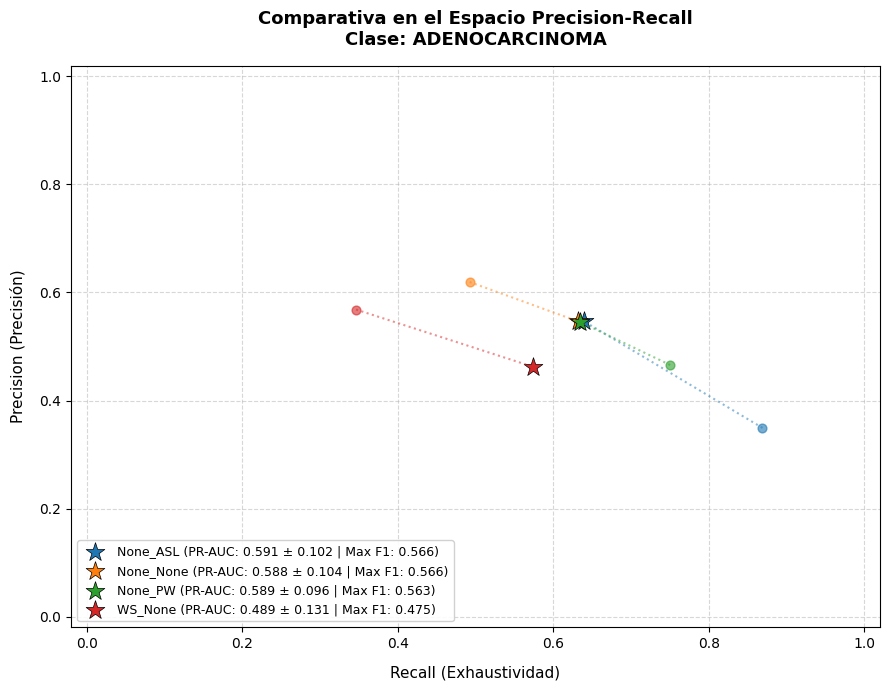

In [3]:
import matplotlib.pyplot as plt
classes = list(data_ASL.keys())

# Iterar por cada clase para generar un gráfico individual
for c in classes:
    # Crear una nueva figura para la clase actual
    plt.figure(figsize=(9, 7))
    
    for m_name, m_data in methods.items():
        # 1. Obtener el valor de PR-AUC (área bajo la curva) para la leyenda
        pr_auc_mean = m_data[c]["independent"]["PR-AUC"]["mean"]
        pr_auc_std = m_data[c]["independent"]["PR-AUC"]["std"]
        
        # 2. Obtener las coordenadas del punto por defecto (Umbral 0.5)
        p_def = m_data[c]["default_0.5"]["precision"]["mean"]
        r_def = m_data[c]["default_0.5"]["recall"]["mean"]
        
        # 3. Obtener las coordenadas del punto optimizado (Máximo F1-Score)
        p_opt = m_data[c]["optimized"]["precision"]["mean"]
        r_opt = m_data[c]["optimized"]["recall"]["mean"]
        f1_opt = m_data[c]["optimized"]["f1_score"]["mean"]
        f1_std = m_data[c]["optimized"]["f1_score"]["std"]
        
        # Dibujar una línea punteada que une el punto por defecto con el optimizado
        line, = plt.plot([r_def, r_opt], [p_def, p_opt], linestyle=':', alpha=0.5, linewidth=1.5)
        color = line.get_color()
        
        # Graficar el punto inicial (Umbral 0.5) como un círculo pequeño
        plt.scatter(r_def, p_def, color=color, marker='o', s=40, alpha=0.6)
        
        # Graficar el punto de F1 Máximo como una ESTRELLA grande
        label_text = f"{m_name} (PR-AUC: {pr_auc_mean:.3f} ± {pr_auc_std:.3f} | Max F1: {f1_opt:.3f})"
        plt.scatter(r_opt, p_opt, color=color, marker='*', s=200, edgecolors='black', linewidths=0.5, label=label_text)
        
    # Configuración estricta del espacio de Precision-Recall
    plt.title(f"Comparativa en el Espacio Precision-Recall\nClase: {c.upper()}", fontsize=13, fontweight='bold', pad=15)
    plt.xlabel("Recall (Exhaustividad)", fontsize=11, labelpad=10)
    plt.ylabel("Precision (Precisión)", fontsize=11, labelpad=10)
    
    # Límites fijos de 0 a 1 para evaluar correctamente el espacio real
    plt.xlim(-0.02, 1.02)
    plt.ylim(-0.02, 1.02)
    
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc="lower left", fontsize=9, framealpha=0.9, shadow=False)
    plt.tight_layout()
    
    # Opcional: Descomenta la siguiente línea si quieres guardar los gráficos directamente en tu carpeta
    # plt.savefig(ROOT / f"Grafico_PR_{c}.png", dpi=300)
    
    # Mostrar el gráfico por pantalla
    plt.show()

In [ ]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# ==========================================
# CONFIGURACIÓN DEL EXPERIMENTO
# ==========================================
CLASSES = [
    'normal',
    'lowgrade_dysplasia',
    'inflammation',
    'highgrade_dysplasia',
    'tumor_necrosis',
    'suspicious_for_invasion',
    'adenocarcinoma',
]
ROOT = Path(r'C:\Users\guigo\OneDrive\Escritorio\TFG_Biopsias\Proyecto\Model_output')


SEEDS = [22, 32, 42, 52, 62]  
FOLDS = [1, 2, 3, 4, 5]
METHODS = ['None_None', 'None_PW', 'None_ASL', 'WS_None']

# CORRECCIÓN: Se cambia 'WS_none' a 'WS_None' para que coincida exactamente con la lista METHODS
COLORS = {
    'None_None': '#1f77b4', 
    'None_PW': '#2ca02c', 
    'None_ASL': '#d62728', 
    'WS_None': '#bcbd22'  # Un tono oliva/amarillo muy elegante para gráficos científicos
}

# CORRECCIÓN: Se añade la traducción de 'WS_None' para que no falle al generar la leyenda
LABELS = {
    'None_None': 'Baseline (BCE)', 
    'None_PW': 'Pos Weights (PW)', 
    'None_ASL': 'Asymmetric Loss (ASL)',
    'WS_None': 'Weighted Sampler (WS)'
}

threshold_sweep = np.linspace(0.01, 0.99, 100)

# Estructura para almacenar las curvas de test de cada combinación
data_storage = {m: {c: {'test_curves': [], 'opt_t_val': [], 'test_f1_opt': []} for c in CLASSES + ['macro_average']} for m in METHODS}

# ==========================================
# EXTRACCIÓN Y PROCESAMIENTO DE DATOS
# ==========================================
print("Procesando archivos CSV y calculando espacios de fases...")

for seed in SEEDS:
    for fold in FOLDS:
        for method in METHODS:
            val_path = ROOT / f"predictions_seed_{seed}_fold{fold}_{method}_val.csv"
            test_path = ROOT / f"predictions_seed_{seed}_fold{fold}_{method}_test.csv"
            
            # Se usa .exists() propio de pathlib que es más robusto
            if not (val_path.exists() and test_path.exists()):
                continue
                
            df_val = pd.read_csv(val_path)
            df_test = pd.read_csv(test_path)
            
            run_macro_test_curve = np.zeros(len(threshold_sweep))
            run_macro_val_curve = np.zeros(len(threshold_sweep))
            
            # --- PASO 1: Calcular curvas por cada clase individual ---
            for cls in CLASSES:
                y_true_val = df_val[f"{cls}_true"].values
                y_prob_val = df_val[f"{cls}_prob"].values
                y_true_test = df_test[f"{cls}_true"].values
                y_prob_test = df_test[f"{cls}_prob"].values
                
                cls_val_curve = []
                cls_test_curve = []
                for t in threshold_sweep:
                    # Validación
                    pred_val = (y_prob_val >= t).astype(int)
                    cls_val_curve.append(f1_score(y_true_val, pred_val, zero_division=0))
                    # Test
                    pred_test = (y_prob_test >= t).astype(int)
                    cls_test_curve.append(f1_score(y_true_test, pred_test, zero_division=0))
                
                cls_test_curve = np.array(cls_test_curve)
                cls_val_curve = np.array(cls_val_curve)
                
                run_macro_test_curve += cls_test_curve / len(CLASSES)
                run_macro_val_curve += cls_val_curve / len(CLASSES)
                
                data_storage[method][cls]['test_curves'].append(cls_test_curve)
                
                best_t_idx = np.argmax(cls_val_curve)
                best_t = threshold_sweep[best_t_idx]
                data_storage[method][cls]['opt_t_val'].append(best_t)
                data_storage[method][cls]['test_f1_opt'].append(cls_test_curve[best_t_idx])
            
            # --- PASO 2: Guardar la métrica combinada Macro de este run ---
            data_storage[method]['macro_average']['test_curves'].append(run_macro_test_curve)
            best_macro_t_idx = np.argmax(run_macro_val_curve)
            data_storage[method]['macro_average']['opt_t_val'].append(threshold_sweep[best_macro_t_idx])
            data_storage[method]['macro_average']['test_f1_opt'].append(run_macro_test_curve[best_macro_t_idx])

# ==========================================
# GENERACIÓN DE IMÁGENES INDIVIDUALES
# ==========================================
print("\nGenerando gráficos individuales...")
plot_targets = CLASSES + ['macro_average']

for target in plot_targets:
    # Creamos un lienzo independiente para cada clase o métrica macro (evitando .figure())
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for method in METHODS:
        curves = np.array(data_storage[method][target]['test_curves'])
        if len(curves) == 0: 
            continue
        
        # Estadísticos de la curva continua (F1 vs Umbral)
        mean_curve = np.mean(curves, axis=0)
        std_curve = np.std(curves, axis=0)
        
        # Estadísticos del punto óptimo validado
        mean_t = np.mean(data_storage[method][target]['opt_t_val'])
        mean_f1 = np.mean(data_storage[method][target]['test_f1_opt'])
        
        # 1. Línea continua de la media
        # Para que el gráfico sea auto-explicativo sin las barras de error, metemos el tau óptimo teórico en la leyenda
        label_text = f"{LABELS[method]} ($\tau^* = {mean_t:.2f}$)"
        ax.plot(threshold_sweep, mean_curve, color=COLORS[method], linestyle='-', linewidth=2, label=label_text)
        
        # 2. Banda de incertidumbre estadística (±1 Desviación Estándar)
        ax.fill_between(threshold_sweep, mean_curve - std_curve, mean_curve + std_curve, 
                        color=COLORS[method], alpha=0.12)
        
        # 3. Marcador del óptimo LIMPIO (Se elimina ax.errorbar y se usa un punto sólido destacado)
        ax.plot(mean_t, mean_f1, marker='o', color=COLORS[method], markersize=8, 
                markeredgecolor='black', markeredgewidth=1.5, zorder=5)
        
    # Formato estético riguroso (Estilo memoria LaTeX / TFG)
    title_name = target.upper().replace('_', ' ')
    if target != 'macro_average':
        ax.set_title(f"Espacio de Calibración: Clase {title_name}", fontsize=13, fontweight='bold', pad=15)
    else:
        ax.set_title("RENDIMIENTO GLOBAL DEL SISTEMA (MACRO OVERALL)", fontsize=13, fontweight='bold', pad=15)
        
    ax.set_xlabel("Umbral de Clasificación ($\tau$)", fontsize=11)
    ax.set_ylabel("F1-Score (Test)", fontsize=11)
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc="lower left", fontsize=10, frameon=True, shadow=True)
    
    plt.tight_layout()
    
    # Guardado individualizado de cada archivo
    filename = f"calibracion_{target}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close(fig)  # Cierra la figura actual para liberar la memoria RAM y evitar solapamientos
    print(f" -> Imagen exportada con éxito: {filename}")

print("\n¡Procesamiento completo! Revisa tu directorio de ejecución.")

Procesando archivos CSV y calculando espacios de fases...

Generando gráficos individuales...
 -> Imagen exportada con éxito: calibracion_normal.png
 -> Imagen exportada con éxito: calibracion_lowgrade_dysplasia.png
 -> Imagen exportada con éxito: calibracion_inflammation.png
 -> Imagen exportada con éxito: calibracion_highgrade_dysplasia.png
 -> Imagen exportada con éxito: calibracion_tumor_necrosis.png
 -> Imagen exportada con éxito: calibracion_suspicious_for_invasion.png
 -> Imagen exportada con éxito: calibracion_adenocarcinoma.png
 -> Imagen exportada con éxito: calibracion_macro_average.png

¡Procesamiento completo! Revisa tu directorio de ejecución.
